In [60]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

dataset = pd.read_csv("PreEmployeeAttrition.csv")
dataset.head()

,Age,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,1,2,94,3,2,4,...,0,0,0,0,0,1,0,0,1,1
1,49,279,8,1,2,3,61,2,2,2,...,0,0,0,0,1,0,0,1,0,0
2,37,1373,2,2,4,4,92,2,1,3,...,1,0,0,0,0,0,0,0,1,1
3,33,1392,3,4,5,4,56,3,1,3,...,0,0,0,0,1,0,0,1,0,1
4,27,591,2,1,7,1,40,3,1,2,...,1,0,0,0,0,0,0,1,0,0


### employees left the company

In [61]:
dataset["Attrition_Yes"].value_counts()

Attrition_Yes
0    1233
1     237
Name: count, dtype: int64

### 
0 = Employee who stayed
#
1 = Employee who left

### department that has the highest number of employees

In [ ]:
department_cols = ["Department_Research & Development","Department_Sales"]
dataset[department_cols].sum()

Department_Research & Development    961
Department_Sales                     446
dtype: int64

### Common education level

In [63]:
dataset["Education"].mode()[0]

np.int64(3)

## Bivariate analysis

In [ ]:
dataset["Attrition"] = dataset["Attrition_Yes"].map({0:"Stayed",1:"Left"})
dataset["Overtime"] = dataset["OverTime_Yes"].map({0:"No Overtime",1:"Overtime"})
dataset["Gender"] = dataset["Gender_Male"].map({0:"Female",1:"Male"})
dataset["Marital Status"] = dataset["MaritalStatus_Married"].map({0:"Not Married",1:"Married"})
dataset["Frequent Travel"] = dataset["BusinessTravel_Travel_Frequently"].map({0:"Not Frequent",1:"Frequent"})
dataset["Manager Role"] = dataset["JobRole_Manager"].map({0:"Other Roles",1:"Manager"})

### Does Overtime affect the Attrition?

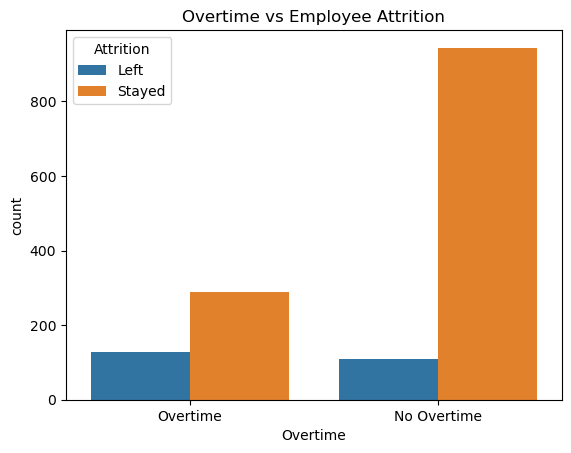

In [ ]:
sns.countplot(x="Overtime",hue="Attrition",data=dataset)

plt.title("Overtime vs Employee Attrition")
plt.show()

### Yes, employees working overtime may show higher attrition rates.

In [ ]:
ct = pd.crosstab(dataset["Overtime"], dataset["Attrition"])
ct

Attrition,Left,Stayed
Overtime,,
No Overtime,110,944
Overtime,127,289


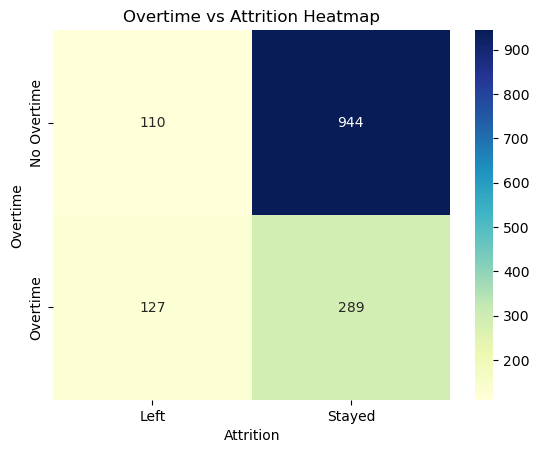

In [ ]:
sns.heatmap(ct,annot=True,cmap="YlGnBu",fmt="d")

plt.title("Overtime vs Attrition Heatmap")
plt.show()

### Chi square for overtime

In [68]:
from scipy.stats import chi2_contingency

chi2_contingency(
    pd.crosstab(
        dataset["Overtime"],
        dataset["Attrition"]
    )
)

Chi2ContingencyResult(statistic=np.float64(87.56429365828768), pvalue=np.float64(8.15842372153832e-21), dof=1, expected_freq=array([[169.93061224, 884.06938776],
       [ 67.06938776, 348.93061224]]))

### Geneder and Attrition

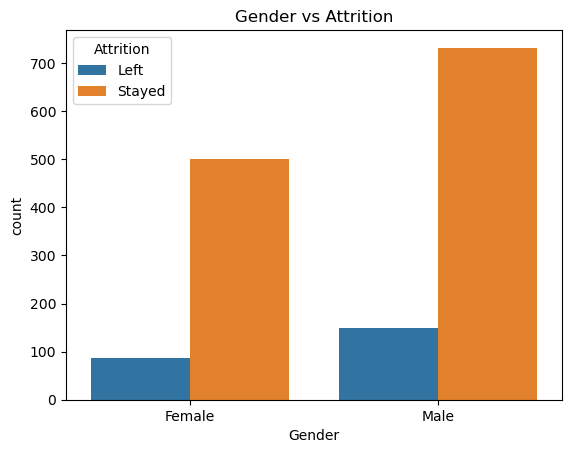

In [ ]:
sns.countplot(x="Gender",hue="Attrition",data=dataset)

plt.title("Gender vs Attrition")
plt.show()

### Chi square for gender

In [70]:
chi2_contingency(
    pd.crosstab(
        dataset["Gender"],
        dataset["Attrition"]
    )
)

Chi2ContingencyResult(statistic=np.float64(1.1169671241970975), pvalue=np.float64(0.29057244902890855), dof=1, expected_freq=array([[ 94.8, 493.2],
       [142.2, 739.8]]))

### Martitial Status and Attrition with chi square

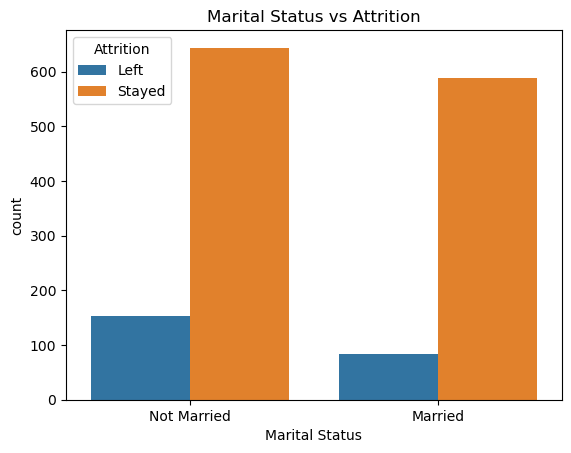

Chi2ContingencyResult(statistic=np.float64(11.67716417184314), pvalue=np.float64(0.0006327189892662448), dof=1, expected_freq=array([[108.50408163, 564.49591837],
       [128.49591837, 668.50408163]]))

In [ ]:
sns.countplot(x="Marital Status",hue="Attrition",data=dataset
)

plt.title("Marital Status vs Attrition")
plt.show()


chi2_contingency(
    pd.crosstab(
        dataset["Marital Status"],
        dataset["Attrition"]
    )
)

### Business Travel and Attrition with Chi Square

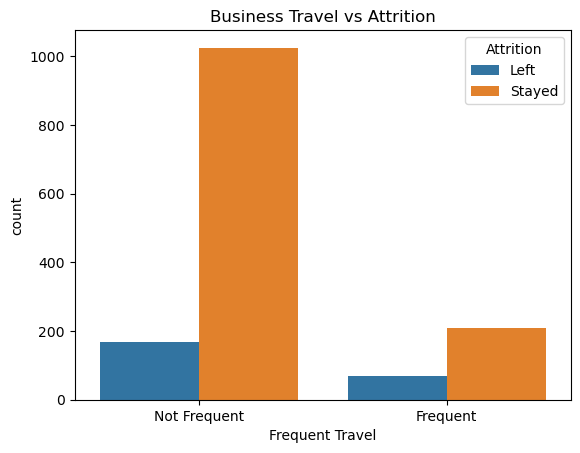

Chi2ContingencyResult(statistic=np.float64(18.69659896377813), pvalue=np.float64(1.5325559632354902e-05), dof=1, expected_freq=array([[  44.65918367,  232.34081633],
       [ 192.34081633, 1000.65918367]]))

In [ ]:
sns.countplot(x="Frequent Travel",hue="Attrition",data=dataset
)

plt.title("Business Travel vs Attrition")
plt.show()

chi2_contingency(
    pd.crosstab(
        dataset["Frequent Travel"],
        dataset["Attrition"]
    )
)

### Manager Role vs Attrition with chi square

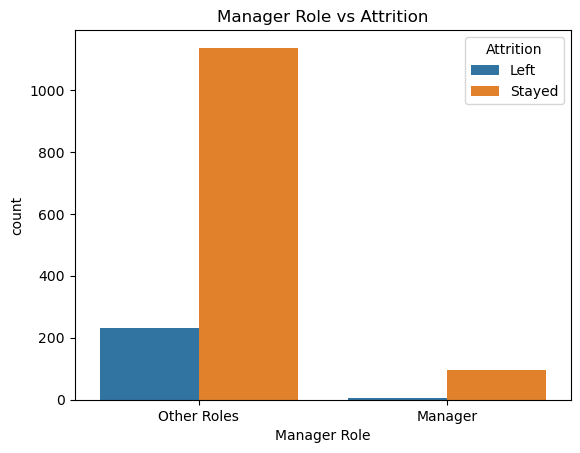

Chi2ContingencyResult(statistic=np.float64(9.332064812359507), pvalue=np.float64(0.002251784807702421), dof=1, expected_freq=array([[  16.44489796,   85.55510204],
       [ 220.55510204, 1147.44489796]]))

In [ ]:
sns.countplot(x="Manager Role",hue="Attrition",data=dataset)

plt.title("Manager Role vs Attrition")
plt.show()

chi2_contingency(
    pd.crosstab(
        dataset["Manager Role"],
        dataset["Attrition"]
    )
)